# Sprint 11
P2P: Ángel

Tarea S11.01. Visualización de Datos con Python y Power BI
Esta práctica integra el uso de Python con las librerías Pandas, Matplotlib, Seaborn o Plotly, así como su integración con Power BI. Trabajarás todo el proceso desde la conexión a MySQL, la creación de visualizaciones avanzadas en Python y finalmente la incorporación de estas visualizaciones a un informe dinámico en Power BI.

## Nivel 1

### 1.1 
1. Conecta Python con MySQL Workbench y carga los datos de tu base de datos del Sprint 4 para utilizarlos en todos los ejercicios.

In [ ]:
# -m pip install pymysql sqlalchemy

In [1]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [2]:
conexion = mysql.connector.connect(
    host="127.0.0.1",
    port=3306,
    user="root",
    password="Vaso$56$raton",
    database="modelado_sql"
)

card_status = pd.read_sql("SELECT * FROM card_status", conexion)
companies = pd.read_sql("SELECT * FROM companies", conexion)
credit_cards = pd.read_sql("SELECT * FROM credit_cards", conexion)
products = pd.read_sql("SELECT * FROM products", conexion)
total_users = pd.read_sql("SELECT * FROM total_users", conexion)
transaction_products = pd.read_sql("SELECT * FROM transaction_products", conexion)
transactions = pd.read_sql("SELECT * FROM transactions", conexion)

C:\Users\miren\AppData\Local\Temp\ipykernel_44220\2699751343.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  card_status = pd.read_sql("SELECT * FROM card_status", conexion)
C:\Users\miren\AppData\Local\Temp\ipykernel_44220\2699751343.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  companies = pd.read_sql("SELECT * FROM companies", conexion)
C:\Users\miren\AppData\Local\Temp\ipykernel_44220\2699751343.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  credit_cards = pd.read_sql("SELECT * FROM credit_cards", conex

Cargamos y comprobamos, (número_de_filas, número_de_columnas)

In [3]:
print("card_status:", card_status.shape)
print("companies:", companies.shape)
print("credit_cards:", credit_cards.shape)
print("products:", products.shape)
print("total_users:", total_users.shape)
print("transaction_products:", transaction_products.shape)
print("transactions:", transactions.shape)

card_status: (5000, 2)
companies: (100, 6)
credit_cards: (5000, 9)
products: (100, 6)
total_users: (5000, 11)
transaction_products: (253391, 2)
transactions: (100000, 10)


In [4]:
card_status.info()
companies.info()
credit_cards.info()
products.info()
total_users.info()
transaction_products.info()
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   card_id  5000 non-null   str  
 1   estado   5000 non-null   str  
dtypes: str(2)
memory usage: 78.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   company_id    100 non-null    str  
 1   company_name  100 non-null    str  
 2   phone         100 non-null    str  
 3   email         100 non-null    str  
 4   country       100 non-null    str  
 5   website       100 non-null    str  
dtypes: str(6)
memory usage: 4.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             5000 non-null   str  
 1   user_id        5000 non-null   int64
 2   

Información sobre los gráficos:

Para algunos análisis ha sido necesario combinar información de varias tablas mediante operaciones de `merge`. 
Se han convertido a formato numérico las columnas necesarias para los análisis.  
También se crean identificadores únicos en los DataFrames que posteriormente se utilizarán en Power BI, ya que Power BI elimina por defecto las filas duplicadas dentro de los visuales de Python.

### 1.2
2. Para cada ítem, crea una visualización adecuada según las variables especificadas. Interpreta los resultados según tus datos.
Recuerda: cuando selecciones las columnas, piensa siempre en el método que utilizarás e incluye las que sean necesarias para la función de visualización que quieras utilizar.

Una variable numérica.

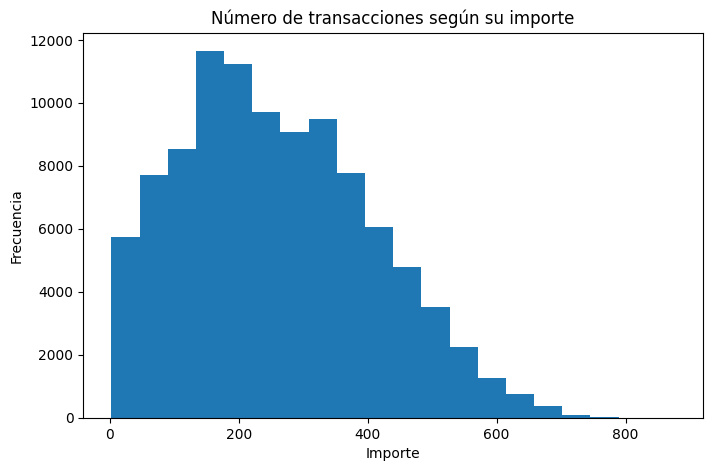

In [5]:
transactions["amount"].plot.hist(bins = 20, figsize=(8,5))
plt.title("Número de transacciones según su importe")   
plt.xlabel("Importe")                                       
plt.ylabel("Frecuencia")                                    
plt.show() 

Interpretación: La mayoría de las transacciones tienen importes entre 100 y 350 €, con un pico sobre 11.500 transacciones alrededor de los 150-200 €. A medida que aumenta el importe, el número de transacciones disminuye.

Dos variables numéricas.

In [6]:
products["price"] = pd.to_numeric(
    products["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.strip(),
    errors="coerce"
)

products["weight"] = pd.to_numeric(
    products["weight"],
    errors="coerce"
)

df_scatter = (
    transaction_products
    .merge(
        transactions,
        left_on="transaction_id",
        right_on="id",
        how="inner"
    )
    .merge(
        products,
        left_on="product_id",
        right_on="id",
        how="inner",
        suffixes=("_transaction", "_product")
    )
)


In [7]:
df_scatter["price"] = pd.to_numeric(df_scatter["price"], errors="coerce")
df_scatter["weight"] = pd.to_numeric(df_scatter["weight"], errors="coerce")
df_scatter["amount"] = pd.to_numeric(df_scatter["amount"], errors="coerce")


In [8]:
df_scatter = df_scatter.reset_index(drop=True)
df_scatter["row_id"] = df_scatter.index

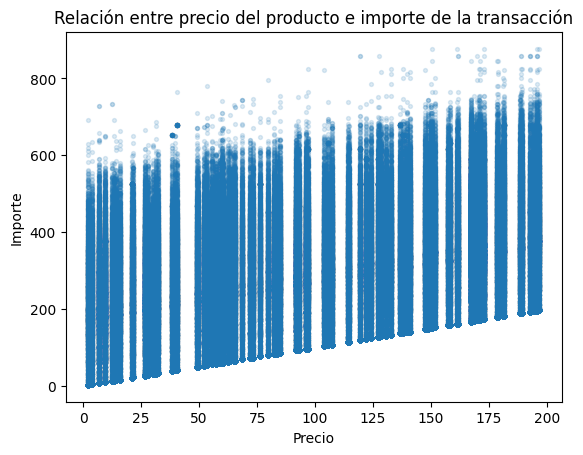

In [9]:
import matplotlib.pyplot as plt

df_scatter.plot.scatter(
    x="price",
    y="amount",
    alpha=0.15,
    s=8
)

plt.title("Relación entre precio del producto e importe de la transacción")
plt.xlabel("Precio")
plt.ylabel("Importe")
plt.show()

Interpretación: Se observa una ligera tendencia ascendente, por lo que, en general, los productos con mayor precio aparecen en transacciones de mayor importe. Sin embargo, para un mismo precio existen importes muy variados, ya que una transacción puede incluir varios productos.

Una variable categórica.

In [10]:
total_users = total_users.reset_index(drop=True)
total_users["row_id"] = total_users.index

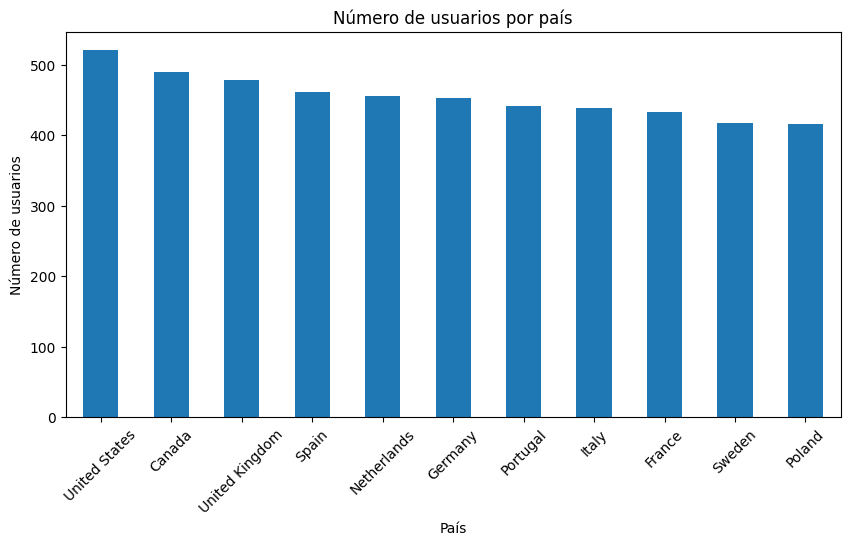

In [11]:
total_users["country"].value_counts().plot.bar(figsize=(10, 5))

plt.title("Número de usuarios por país")          
plt.xlabel("País")                                
plt.ylabel("Número de usuarios")                  
plt.xticks(rotation=45)                           
plt.show()                                        

Interpretación: Estados Unidos concentra el mayor número de usuarios, mientras que Suecia y Polonia presentan los valores más bajos. En general, las diferencias entre países son reducidas, en un rango que ronda el centenar de usuarios.

Una variable categórica y una numérica.

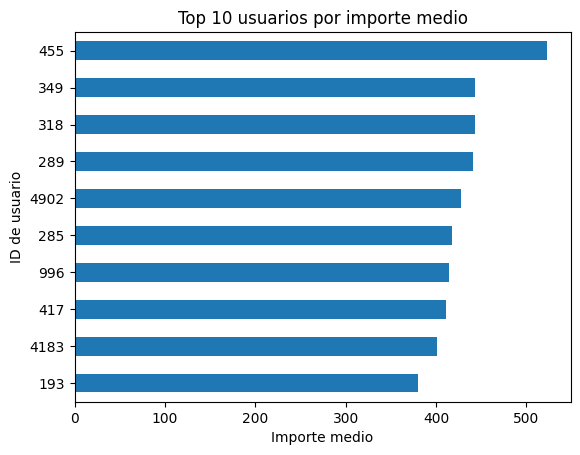

In [12]:
transactions.groupby("user_id")["amount"].mean().nlargest(10).sort_values().plot.barh()
            
plt.title("Top 10 usuarios por importe medio")          
plt.xlabel("Importe medio")                             
plt.ylabel("ID de usuario")                             
plt.show()                                              


Interpretación: El usuario 455 registra el mayor importe medio de las transacciones, superando las 500; el resto de usuarios del Top 10 presentan valores similares.

Dos variables categóricas.

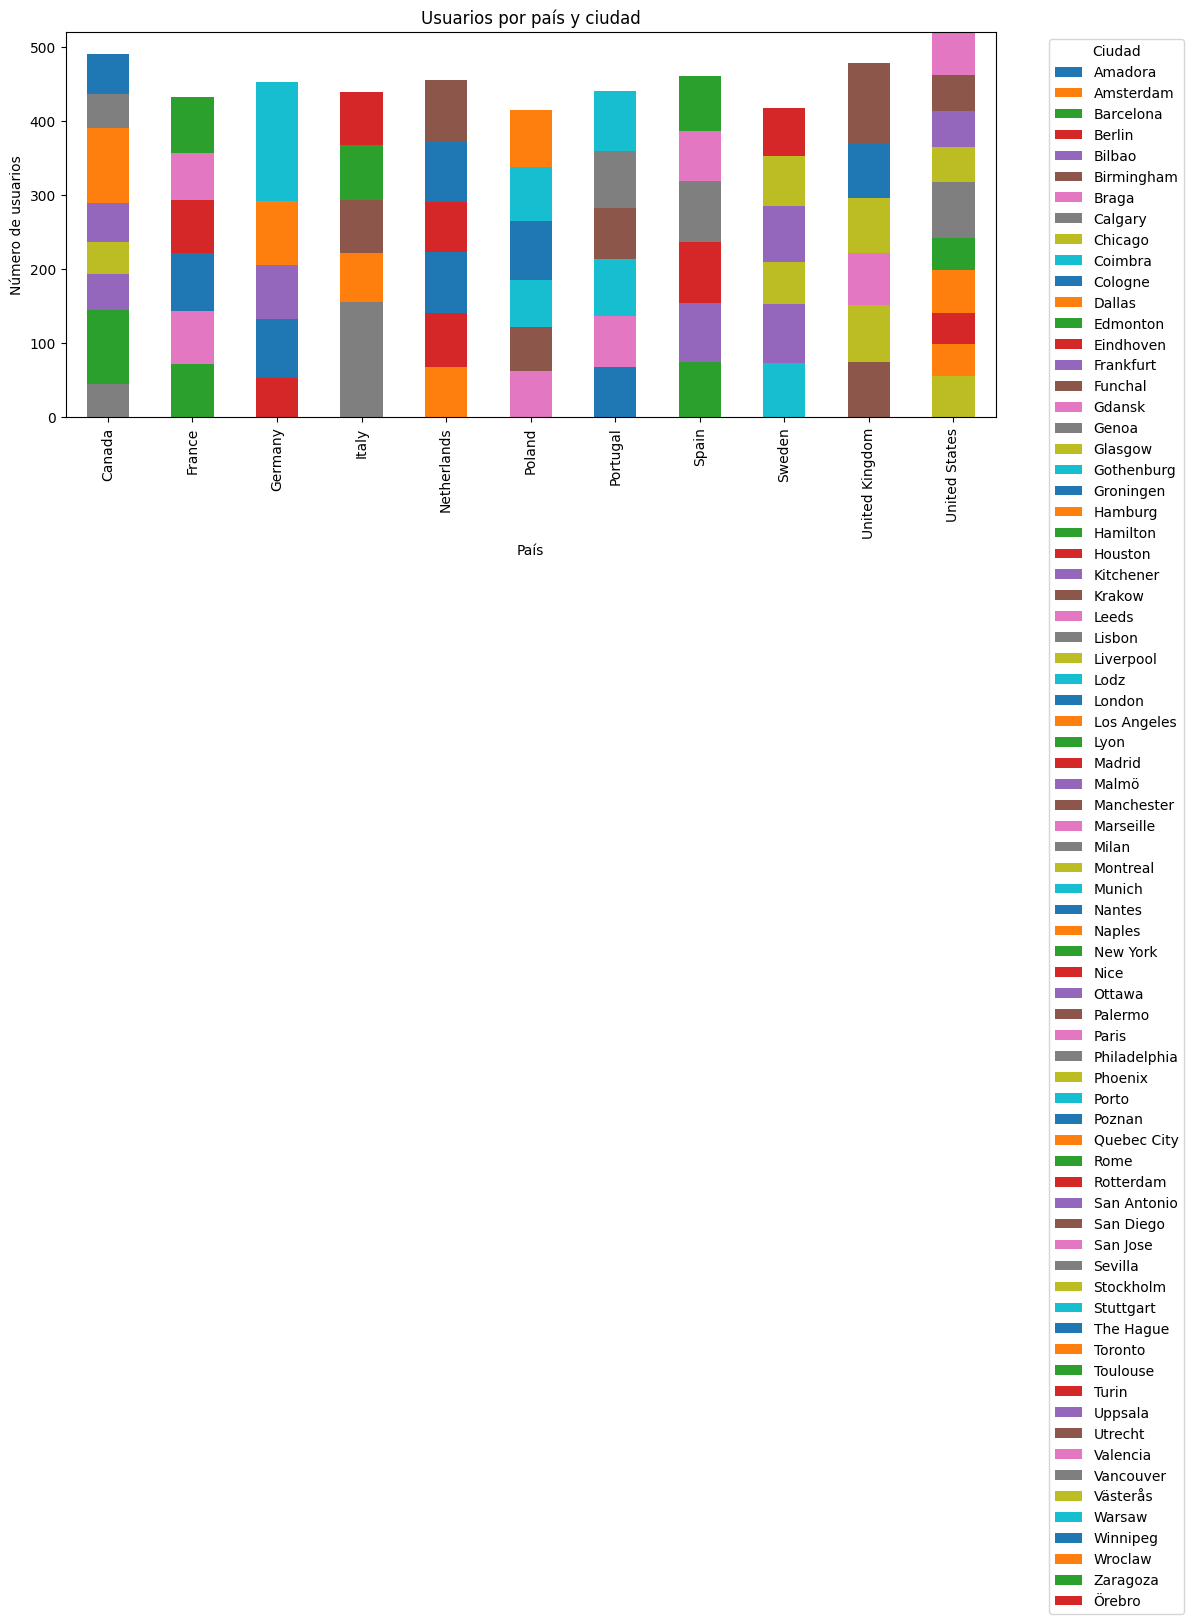

In [13]:
pd.crosstab( total_users["country"], total_users["city"]).plot.bar(stacked=True, figsize=(12,5))

plt.title("Usuarios por país y ciudad")                  
plt.xlabel("País")                                      
plt.ylabel("Número de usuarios")                         
plt.legend(title="Ciudad", bbox_to_anchor=(1.05, 1))     
plt.show()                                               


Interpretación: Se aprecia una mayor concentración de usuarios en Milán (gris) y Stuttgart (azul cielo), que registran las frecuencias más elevadas. El resto de ciudades presentan un número de usuarios inferior y sin grandes diferencias entre ellas.

Tres variables combinadas.

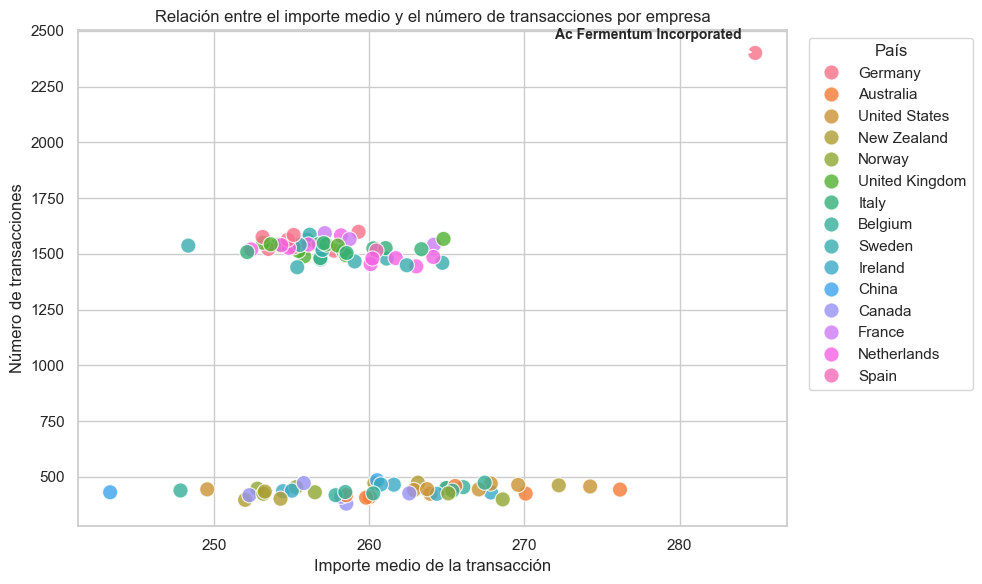

In [14]:

import matplotlib.pyplot as plt
import seaborn as sns

empresa_resum = (
    transactions
    .groupby("business_id")
    .agg(
        num_transacciones=("amount", "count"),
        importe_medio=("amount", "mean")
    )
    .reset_index()
)

empresa_resum = empresa_resum.merge(
    companies[["company_id", "company_name", "country"]],
    left_on="business_id",
    right_on="company_id",
    how="left"
)

empresa_outlier = empresa_resum.loc[
    empresa_resum["num_transacciones"].idxmax()
]

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=empresa_resum,
    x="importe_medio",
    y="num_transacciones",
    hue="country",
    s=120,
    alpha=0.8
)

plt.annotate(
    empresa_outlier["company_name"],
    (
        empresa_outlier["importe_medio"],
        empresa_outlier["num_transacciones"]
    ),
    xytext=(-10, 10),
    textcoords="offset points",
    ha="right",
    fontsize=10,
    fontweight="bold",
    arrowprops={
        "arrowstyle": "->",
        "linewidth": 1
    }
)

plt.title("Relación entre el importe medio y el número de transacciones por empresa")
plt.xlabel("Importe medio de la transacción")
plt.ylabel("Número de transacciones")

plt.legend(
    title="País",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Interpretación: El importe medio de las transacciones es similar entre la mayoría de las empresas, mientras que el volumen de transacciones muestra una gran variabilidad. Destaca Ac Fermentum Incorporated como un valor atípico por el elevado número de transacciones registradas.

Crea un Pairplot.



Este pairplot compara tres variables numéricas agregadas por empresa para analizar las posibles relaciones entre el volumen de transacciones, el importe medio y el importe total generado.

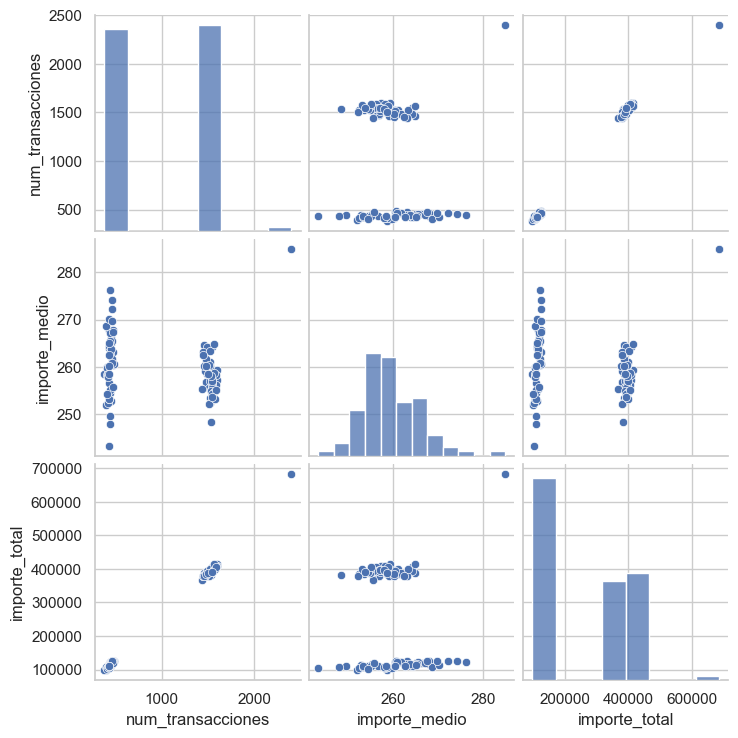

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

empresa_resum = (
    transactions
    .groupby("business_id")
    .agg(
        num_transacciones=("amount", "count"),
        importe_medio=("amount", "mean"),
        importe_total=("amount", "sum")
    )
    .reset_index()
)

sns.set_theme(style="whitegrid")

sns.pairplot(
    empresa_resum[
        [
            "num_transacciones",
            "importe_medio",
            "importe_total"
        ]
    ],
    diag_kind="hist",
    height=2.5
)

plt.show()

Se observa una fuerte relación entre el número de transacciones y el importe total, mientras que el importe medio presenta una variación menor entre empresas. No se aprecian patrones anómalos, salvo alguna empresa con un volumen de transacciones superior al resto.

## Nivel 2

### 2.1
1. Representa la correlación de algunas variables e interpreta los resultados según tus datos.

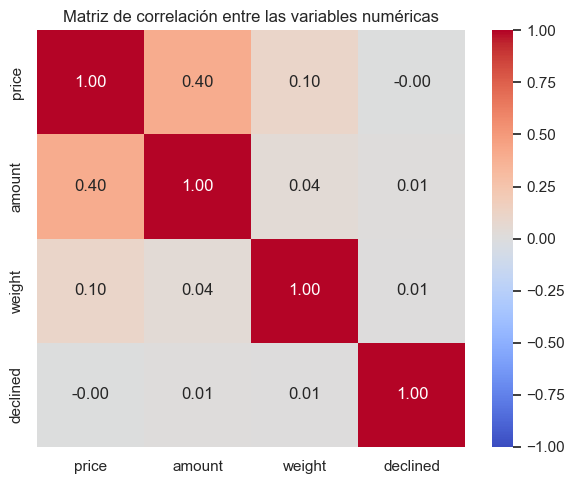

In [16]:
df_corr = df_scatter[["price", "amount", "weight", "declined"]].dropna()
correlation_matrix = df_corr.corr()

plt.figure(figsize=(6, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlación entre las variables numéricas")
plt.tight_layout()
plt.show()


Interpretación: La matriz de correlación muestra la relación lineal entre las variables numéricas. Se observa una correlación positiva moderada entre el precio y el importe de la transacción (0,40). En cambio, el peso presenta una correlación muy débil con el resto de variables y el estado de la transacción (declined) prácticamente no muestra relación con ninguna de ellas.

### 2.2
2. Implementa un Jointplot para explorar la relación entre dos variables e interpreta los resultados según tus datos.

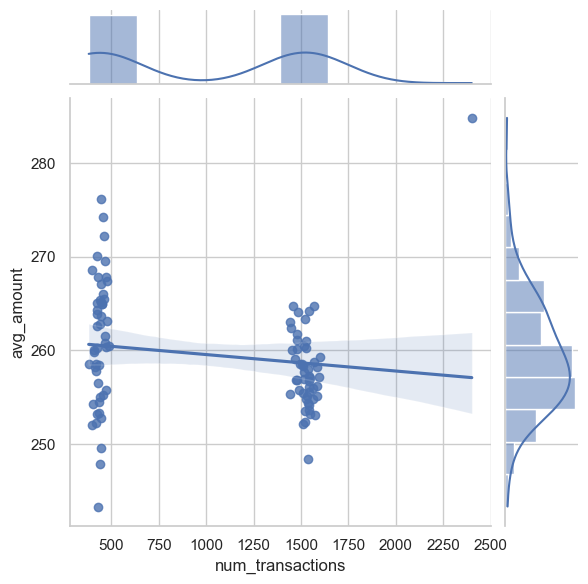

In [17]:
df_joint = transactions.groupby("business_id").agg(
    num_transactions=("id", "count"),
    avg_amount=("amount", "mean")
).reset_index()

sns.jointplot(
    data=df_joint,
    x="num_transactions",
    y="avg_amount",
    kind="reg"
)

plt.show()

Interpretación: En el eje X se representa el número de transacciones por empresa y en el eje Y el importe medio de las transacciones. Se observa una ligera tendencia descendente, lo que indica que las empresas con un mayor número de transacciones tienden a presentar un importe medio ligeramente inferior.

## Nivel 3

### 3.1
1. Transfiere todas las visualizaciones del Nivel 1 a Power BI utilizando scripts de Python.

Recuerda: cuando cargue tus dataframas en Power BI, asegúrate de incluir una columna identificadora o una combinación de columnas que garantice la unicidad de cada registro. Por defecto, Power BI elimina duplicados y podrías perder información.

las visualizaciones de Power BI se adjuntarán en archivo .pbix
fin sprint 11